# Трансформер своими руками. Часть 2 — кирпичики, с кодом

В части 1 мы посмотрели на архитектуру с высоты птичьего полёта. Теперь спустимся на землю и соберём каждый блок руками. Формат для каждого кирпичика один и тот же: интуиция → формула → код на PyTorch → эталонная реализация на чистом numpy для сверки → честный подсчёт сложности этого блока.

Зачем numpy-эталон? PyTorch-модули удобны, но прячут детали за вызовами библиотеки. Реализация тех же вычислений «вручную» на numpy не оставляет места недопониманию: если два независимых кода дают одинаковые числа, значит, мы действительно понимаем, что происходит внутри. Каждый блок мы будем сверять через `np.allclose`.

Обозначения на всю серию: $n$ — длина последовательности, $d$ — размерность модели, $h$ — число голов внимания, $d_{ff}$ — внутренняя размерность FFN, $|V|$ — размер словаря.

Один момент, который мы оставим за кадром: токенизацию. Мы считаем, что текст уже превращён в последовательность целочисленных идентификаторов токенов — как именно текст режется на токены (обычно алгоритмом BPE), хорошо описано, например, в [главе курса Лены Войты](https://lena-voita.github.io/nlp_course/seq2seq_and_attention.html) и в статье [Sennrich et al., 2016](https://arxiv.org/abs/1508.07909).

Настроим окружение:

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(0)
np.random.seed(0)

n, d, h, d_ff, vocab_size = 6, 16, 4, 64, 100  # игрушечные размеры для проверок

## Токены → эмбеддинги

**Интуиция.** Модель не умеет работать с номерами токенов напрямую — ей нужны векторы. Таблица эмбеддингов — это просто матрица $E$ размера $|V| \times d$: по строке на каждый токен словаря. «Превратить токен в вектор» значит взять из матрицы строку с номером этого токена.

**Формула.** Для последовательности идентификаторов $t_1, \dots, t_n$:

$$
X = (E_{t_1}, \dots, E_{t_n}) \in \mathbb{R}^{n \times d}.
$$

**Код.** В PyTorch это `nn.Embedding`, в numpy — обычная индексация:

In [2]:
emb = nn.Embedding(vocab_size, d)
token_ids = torch.randint(0, vocab_size, (n,))

x_torch = emb(token_ids)                            # (n, d)

E = emb.weight.detach().numpy()                     # (|V|, d)
x_np = E[token_ids.numpy()]                         # та же операция руками

assert np.allclose(x_torch.detach().numpy(), x_np)
print("эмбеддинги: ок", x_torch.shape)

эмбеддинги: ок torch.Size([6, 16])


**Сложность.** Никаких умножений: $n$ обращений к строкам таблицы, на выходе матрица $n \times d$ — то есть $O(n \cdot d)$ по объёму результата. Основная цена эмбеддингов не в вычислениях, а в параметрах: $|V| \cdot d$ чисел, при большом словаре это заметная часть модели.

Небольшая деталь из оригинальной статьи: перед подачей в модель эмбеддинги умножаются на $\sqrt{d}$ — чтобы их масштаб не терялся на фоне positional encoding, который мы сейчас к ним прибавим. Мы учтём это при сборке полной модели в части 3.

## Positional encoding

**Интуиция.** В части 1 мы выяснили: self-attention не видит порядок токенов — взвешенной сумме всё равно, в каком порядке стоят слагаемые. Для языка это катастрофа («кот съел мышь» и «мышь съела кота» — разные события), поэтому информацию о позиции нужно вернуть в модель явно. Решение оригинальной статьи: к эмбеддингу каждого токена прибавить вектор, зависящий только от *позиции* токена в последовательности.

**Формула.** Позиционный вектор для позиции $pos$ составлен из синусов и косинусов разных частот:

$$
PE_{(pos,\, 2i)} = \sin\!\left(\frac{pos}{10000^{2i/d}}\right), \qquad
PE_{(pos,\, 2i+1)} = \cos\!\left(\frac{pos}{10000^{2i/d}}\right),
$$

где $i$ пробегает пары координат. Каждая пара координат — это своя «стрелка часов»: первые пары крутятся быстро (меняются от токена к токену), последние — очень медленно. Набор из $d/2$ таких стрелок однозначно кодирует позицию, как часы с секундной, минутной и часовой стрелками кодируют время.

**Код.**

In [3]:
def positional_encoding(n, d):
    pos = torch.arange(n).unsqueeze(1)               # (n, 1)
    i = torch.arange(0, d, 2)                        # (d/2,)
    angles = pos / 10000 ** (i / d)                  # (n, d/2)
    pe = torch.zeros(n, d)
    pe[:, 0::2] = torch.sin(angles)
    pe[:, 1::2] = torch.cos(angles)
    return pe

def positional_encoding_np(n, d):
    pos = np.arange(n)[:, None]
    i = np.arange(0, d, 2)
    angles = pos / 10000 ** (i / d)
    pe = np.zeros((n, d))
    pe[:, 0::2] = np.sin(angles)
    pe[:, 1::2] = np.cos(angles)
    return pe

pe = positional_encoding(n, d)
assert np.allclose(pe.numpy(), positional_encoding_np(n, d), atol=1e-6)
print("positional encoding: ок", pe.shape)

positional encoding: ок torch.Size([6, 16])


Полезно один раз увидеть эту матрицу глазами:

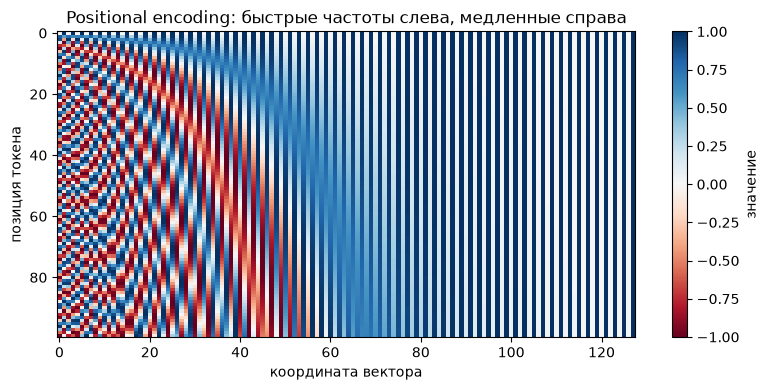

In [4]:
import matplotlib.pyplot as plt

pe_big = positional_encoding(100, 128)
plt.figure(figsize=(8, 4))
plt.imshow(pe_big.numpy(), aspect="auto", cmap="RdBu")
plt.xlabel("координата вектора")
plt.ylabel("позиция токена")
plt.colorbar(label="значение")
plt.title("Positional encoding: быстрые частоты слева, медленные справа")
plt.tight_layout()
plt.show()

![](transformer_pictures/positional_encoding.png)

Каждый столбец — одна координата вектора, каждая строка — позиция в последовательности. Левые координаты осциллируют быстро и различают соседние токены, правые меняются медленно и кодируют «крупный масштаб» позиции.

**Сложность.** Прибавить к каждому из $n$ векторов размера $d$ позиционный вектор — $O(n \cdot d)$. Сами позиционные векторы не обучаются и считаются один раз.

## Scaled dot-product attention

Центральный блок всей архитектуры.

**Интуиция.** В части 0 attention работал так: есть запрос (состояние декодера), есть набор кандидатов (состояния энкодера), считаем релевантность каждого кандидата запросу и берём взвешенную сумму. Обобщим это до трёх ролей, в которых может выступать вектор:

- **query** $q$ — «что я ищу»;
- **key** $k$ — «по какому признаку меня можно найти»;
- **value** $v$ — «что я отдам, если меня выберут».

Аналогия — поиск по библиотеке: запрос сравнивается с карточками каталога (keys), и по результатам сравнения выдаётся смесь книг (values). Важно, что «карточка» и «книга» — разные объекты: токен может быть *найден* по одному признаку, а *отдавать* совсем другую информацию.

![](transformer_pictures/queries_keys_values.png)

*Источник изображения:* https://lena-voita.github.io/nlp_course/seq2seq_and_attention.html

На схеме каждый вектор получает три роли через три матрицы $W^Q$, $W^K$, $W^V$ — эти обучаемые проекции появятся у нас чуть ниже, в multi-head attention; сама операция внимания, которую мы сейчас напишем, принимает уже готовые $Q$, $K$, $V$.

**Формула.** Запросы, ключи и значения складываем в матрицы $Q$ ($n_q \times d_k$), $K$, $V$ ($n_k \times d_k$ и $n_k \times d_v$):

$$
\mathrm{Attention}(Q, K, V) = \mathrm{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}}\right)V.
$$

Здесь $QK^\top$ — уже знакомая по частям 0–1 таблица скоров «каждый запрос против каждого ключа», softmax превращает каждую строку в распределение весов, а умножение на $V$ берёт взвешенные суммы значений.

> 💡 **Почему $\sqrt{d_k}$, а не $d_k$ и не ничего?** Скалярное произведение двух случайных векторов из $d_k$ независимых компонент с нулевым средним и единичной дисперсией имеет дисперсию $d_k$ ([аккуратный вывод через свойства дисперсии произведения независимых величин](https://ai.stackexchange.com/questions/21237/why-does-this-multiplication-of-q-and-k-have-a-variance-of-d-k-in-scaled)) — то есть типичный размах скоров растёт как $\sqrt{d_k}$. Казалось бы, softmax'у важен не масштаб, а только относительные величины скоров. Выпишем формулу и проверим: для вектора скоров $s = (s_1, \dots, s_n)$ вес $i$-го элемента
>
> $$
> p_i = \mathrm{softmax}(s)_i = \frac{e^{s_i}}{\sum_{k=1}^{n} e^{s_k}}.
> $$
>
> Для *сдвига* интуиция верна: прибавим ко всем скорам константу $c$ — числитель и каждое слагаемое знаменателя умножатся на $e^c$, общий множитель сократится, веса не изменятся. А вот *умножение* скоров на константу не сокращается: оно растягивает разности между скорами, от которых softmax зависит по-настоящему — поделив $p_i$ на $p_j$, видим $p_i / p_j = e^{s_i - s_j}$. Дисперсия $d_k$ означает, что типичная разность между двумя скорами — порядка $\sqrt{d_k}$ по модулю; при $d_k = 512$ это десятки, а уже разность логитов в 20 даёт отношение весов $e^{20} \approx 5 \cdot 10^8$. Знак разности при этом неважен. Чтобы это увидеть, поделим у веса наибольшего скора $s_{\max}$ числитель и знаменатель на $e^{s_{\max}}$:
>
> $$
> p_{\max} = \frac{e^{s_{\max}}}{\sum_{k} e^{s_k}} = \frac{1}{1 + \sum_{k \neq \max} e^{s_k - s_{\max}}}.
> $$
>
> Все показатели $s_k - s_{\max}$ отрицательны, и если по модулю они порядка десятков, каждое слагаемое в знаменателе $\sim e^{-20} \approx 2 \cdot 10^{-9}$ — то есть $p_{\max} \approx 1$: наибольший скор забирает почти весь вес. А наибольший есть всегда. В этом и проблема: веса на старте случайны, так что attention «намертво» выбирает *случайный* токен, а градиенты через остальные практически нулевые — исправить неудачный выбор обучению крайне трудно. Деление на $\sqrt{d_k}$ возвращает разностям масштаб порядка единицы. А почему не поделить на $d_k$? Тогда типичные разности сожмутся до $1/\sqrt{d_k}$. Экспонента на малых аргументах уже не страшна — она линейна, $e^x \approx 1 + x$, — так что отношения весов $p_i/p_j \approx 1 \pm 1/\sqrt{d_k}$: при $d_k = 512$ все веса почти равны, отличаясь на считанные проценты. Softmax становится почти равномерным, и attention не выбирает, а просто усредняет все значения. Заметьте: этот провал мягче предыдущего — градиенты здесь живые, но модели пришлось бы выучивать проекции с большей нормой, вытягивая разности обратно на масштаб единицы, против навязанного деления. Деление на $\sqrt{d_k}$ — золотая середина: разности порядка 1, softmax избирателен, но не намертво, и обучаем в обе стороны. Проверим дисперсию экспериментально:
>
> ```python
> d_ks = 2 ** np.arange(2, 13)                     # 4 ... 4096
> var_raw, var_scaled = [], []
> for d_k in d_ks:
>     q = np.random.randn(2000, d_k)
>     k = np.random.randn(2000, d_k)
>     scores = (q * k).sum(axis=1)
>     var_raw.append(scores.var())
>     var_scaled.append((scores / np.sqrt(d_k)).var())
>
> plt.figure(figsize=(7, 3.5))
> plt.loglog(d_ks, d_ks, "--", color="gray", label="теория: $\\mathrm{var} = d_k$")
> plt.loglog(d_ks, var_raw, "o-", label="var($q \\cdot k$)")
> plt.loglog(d_ks, var_scaled, "s-", label="var($q \\cdot k \\,/\\, \\sqrt{d_k}$)")
> plt.xlabel("$d_k$")
> plt.ylabel("дисперсия скоров")
> plt.grid(alpha=0.3)
> plt.legend()
> plt.tight_layout()
> plt.show()
> ```
>
> ![](transformer_pictures/score_variance.png)
>
> Дисперсия «сырых» скоров ложится точно на линию $\mathrm{var} = d_k$, отмасштабированных — держится около 1 при любой размерности.

**Код.** Сама операция — четыре строки:

In [5]:
def scaled_dot_product_attention(q, k, v, mask=None):
    scores = q @ k.transpose(-2, -1) / q.shape[-1] ** 0.5   # (..., n_q, n_k)
    if mask is not None:
        scores = scores.masked_fill(~mask, float("-inf"))
    weights = F.softmax(scores, dim=-1)                     # (..., n_q, n_k)
    return weights @ v, weights

**Numpy-эталон.** Softmax напишем сами (с вычитанием максимума для численной устойчивости):

In [6]:
def softmax_np(x, axis=-1):
    x = x - x.max(axis=axis, keepdims=True)
    e = np.exp(x)
    return e / e.sum(axis=axis, keepdims=True)

def attention_np(q, k, v, mask=None):
    scores = q @ np.swapaxes(k, -2, -1) / np.sqrt(q.shape[-1])
    if mask is not None:
        scores = np.where(mask, scores, -np.inf)
    weights = softmax_np(scores)
    return weights @ v, weights

q, k, v = torch.randn(n, d), torch.randn(n, d), torch.randn(n, d)
out_torch, w_torch = scaled_dot_product_attention(q, k, v)
out_np, w_np = attention_np(q.numpy(), k.numpy(), v.numpy())

assert np.allclose(out_torch.numpy(), out_np, atol=1e-6)
assert np.allclose(w_torch.numpy(), w_np, atol=1e-6)
print("scaled dot-product attention: ок", out_torch.shape)

scaled dot-product attention: ок torch.Size([6, 16])


**Сложность** (при $n_q = n_k = n$, $d_k = d_v = d$):

- $QK^\top$: перемножение $(n \times d)$ на $(d \times n)$ — $O(n^2 \cdot d)$;
- softmax: по $n$ элементов в каждой из $n$ строк — $O(n^2)$;
- взвешенная сумма $\mathrm{weights} \cdot V$: $(n \times n)$ на $(n \times d)$ — $O(n^2 \cdot d)$.

Итого $O(n^2 \cdot d)$, и это та самая квадратичность по длине последовательности из части 1. Заметьте: параметров у этого блока *ноль* — все обучаемые веса появятся уровнем выше, в multi-head attention.

## Multi-head attention

**Интуиция.** Один attention — один «взгляд» на последовательность: одна таблица весов на пару токенов. Но токены связаны по-разному одновременно: синтаксически, по смыслу, по кореференции («он» → «кот»). Идея multi-head: запустить $h$ маленьких attention параллельно, каждый в своём подпространстве размерности $d/h$, — и позволить каждой голове выучить свой тип связей.

![](transformer_pictures/multihead_attention.png)

*Источник изображения:* https://lena-voita.github.io/nlp_course/seq2seq_and_attention.html

**Формула.** Вход $X$ ($n \times d$) сначала проходит три обучаемые линейные проекции:

$$
Q = XW^Q, \quad K = XW^K, \quad V = XW^V, \qquad W^Q, W^K, W^V \in \mathbb{R}^{d \times d}.
$$

Затем $Q, K, V$ *разрезаются* по координатам на $h$ голов размера $n \times d/h$, каждая голова считает обычный scaled dot-product attention (со шкалой $\sqrt{d/h}$ — размерность головы!), результаты склеиваются обратно в $n \times d$ и проходят выходную проекцию $W^O \in \mathbb{R}^{d \times d}$:

$$
\mathrm{head}_i = \mathrm{Attention}(Q_i, K_i, V_i), \qquad
\mathrm{MultiHead}(X) = \mathrm{Concat}(\mathrm{head}_1, \dots, \mathrm{head}_h)\,W^O.
$$

Вот, кстати, и обещанный в части 1 ответ, зачем нужны три разные проекции: они и создают роли query/key/value — без них токен был бы обязан «искать» и «быть найденным» одним и тем же вектором.

> 💡 **Почему в softmax делим на $\sqrt{d/h}$, а не на $\sqrt{d}$?** Потому что скалярные произведения считаются *внутри головы*, между векторами размерности $d/h$ — значит, и дисперсия скоров растёт как $d/h$, и нормировать надо на неё. Общий принцип: делим на корень из размерности векторов, которые реально перемножаем.

**Код.**

In [7]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d, h):
        super().__init__()
        assert d % h == 0
        self.d, self.h, self.d_head = d, h, d // h
        self.w_q = nn.Linear(d, d, bias=False)
        self.w_k = nn.Linear(d, d, bias=False)
        self.w_v = nn.Linear(d, d, bias=False)
        self.w_o = nn.Linear(d, d, bias=False)

    def split_heads(self, x):          # (n, d) -> (h, n, d/h)
        n = x.shape[0]
        return x.view(n, self.h, self.d_head).transpose(0, 1)

    def forward(self, x_q, x_k, x_v, mask=None):
        q = self.split_heads(self.w_q(x_q))
        k = self.split_heads(self.w_k(x_k))
        v = self.split_heads(self.w_v(x_v))
        out, weights = scaled_dot_product_attention(q, k, v, mask)
        n = out.shape[1]
        concat = out.transpose(0, 1).reshape(n, self.d)   # склейка голов
        return self.w_o(concat), weights

Для self-attention все три входа — одна и та же последовательность: `mha(x, x, x)`. Для cross-attention из части 1 запросы придут от декодера, а ключи и значения — от энкодера: `mha(dec, enc, enc)` — код один и тот же.

> 💡 **Разрезание на головы бесплатно.** `view` и `transpose` в PyTorch (как и `reshape` в numpy) не копируют и не перемещают числа — они меняют только *метаданные* тензора: размеры и шаги обхода памяти. «Разрезали на $h$ голов и склеили обратно» звучит как работа, но фактически это переинтерпретация той же самой памяти.

**Numpy-эталон.** Возьмём веса из PyTorch-модуля и повторим все шаги руками (`nn.Linear` хранит матрицу транспонированной, поэтому `.T`):

In [8]:
def multi_head_attention_np(x, w_q, w_k, w_v, w_o, h):
    n, d = x.shape
    d_head = d // h

    def split(m):                       # (n, d) -> (h, n, d/h)
        return m.reshape(n, h, d_head).transpose(1, 0, 2)

    q, k, v = split(x @ w_q), split(x @ w_k), split(x @ w_v)
    out, _ = attention_np(q, k, v)
    concat = out.transpose(1, 0, 2).reshape(n, d)
    return concat @ w_o

mha = MultiHeadAttention(d, h)
x = torch.randn(n, d)
out_torch, _ = mha(x, x, x)

weights_np = [m.weight.detach().numpy().T for m in (mha.w_q, mha.w_k, mha.w_v, mha.w_o)]
out_np = multi_head_attention_np(x.numpy(), *weights_np, h)

assert np.allclose(out_torch.detach().numpy(), out_np, atol=1e-6)
print("multi-head attention: ок", out_torch.shape)

multi-head attention: ок torch.Size([6, 16])


**Сложность, построчно.** Пройдём по forward сверху вниз:

| Шаг | Операция | Сложность |
|---|---|---|
| Проекции $XW^Q, XW^K, XW^V$ | $(n \times d) \cdot (d \times d)$, трижды | $O(n \cdot d^2)$ |
| Разрезание на головы | метаданные | $O(1)$* |
| $Q_i K_i^\top$ на голову | $(n \times d/h) \cdot (d/h \times n)$ | $O(n^2 \cdot d/h)$ |
| …на все $h$ голов | | $O(n^2 \cdot d)$ |
| softmax на голову | $n \times n$ элементов | $O(n^2)$, на все головы $O(n^2 \cdot h)$ |
| $\mathrm{weights}_i \cdot V_i$ на все головы | | $O(n^2 \cdot d)$ |
| Склейка голов | метаданные + копия $n \times d$ | $O(n \cdot d)$ |
| Выходная проекция $W^O$ | $(n \times d) \cdot (d \times d)$ | $O(n \cdot d^2)$ |

\* — если требуется физически непрерывная память (как перед `reshape` после `transpose`), копирование стоит $O(n \cdot d)$; на итог это не влияет.

**Итого: $O(n^2 \cdot d + n \cdot d^2)$.** Первое слагаемое — сам attention (квадрат по длине), второе — проекции (квадрат по размерности модели). Кто из них главный — зависит от соотношения $n$ и $d$; подробный разбор боттлнеков будет в сводке в части 3. Обратите внимание: разрезание на $h$ голов *не меняет* суммарную сложность по сравнению с одной большой головой — работа та же, просто поделена на независимые куски.

## Маски

Attention в том виде, как мы его написали, разрешает каждому токену смотреть на все токены. Это не всегда допустимо — в обзоре архитектуры в части 1 мы уже упоминали, что self-attention в декодере работает с маской, запрещающей подглядывать в будущее. По-настоящему маски заработают в части 3, когда мы соберём декодер и обучение, — но механика запретов принадлежит самому блоку attention (параметр `mask` уже стоит в нашей реализации), поэтому разберём её здесь, чтобы при сборке применять готовую деталь одной строкой.

Маска — булева матрица, где `True` = «смотреть можно». Запрещённым позициям мы присваиваем скор $-\infty$ *до* softmax: после экспоненты они превратятся в честный ноль веса, и распределение по разрешённым позициям останется корректным (сумма 1).

Масок в трансформере две:

**Padding-маска.** Последовательности в батче имеют разную длину, и короткие дополняются служебным токеном `<pad>` до общей длины. Смотреть на `<pad>` бессмысленно — это не текст, а упаковочный материал.

**Causal-маска (декодер).** Декодер обучается предсказывать следующий токен, и токен на позиции $t$ не имеет права видеть позиции $> t$ — иначе задача предсказания превращается в подглядывание ответа. Маска нижнетреугольная:

In [9]:
def causal_mask(n):
    return torch.tril(torch.ones(n, n, dtype=torch.bool))

Нарисуем её для знакомого предложения:

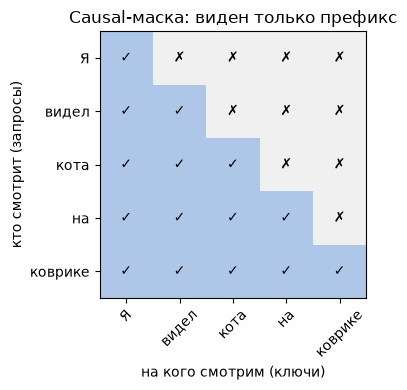

In [10]:
from matplotlib.colors import ListedColormap

tokens = ["Я", "видел", "кота", "на", "коврике"]
m = causal_mask(len(tokens)).int().numpy()

plt.figure(figsize=(4.5, 4))
plt.imshow(m, cmap=ListedColormap(["#f0f0f0", "#aec7e8"]))
plt.xticks(range(len(tokens)), tokens, rotation=45)
plt.yticks(range(len(tokens)), tokens)
plt.xlabel("на кого смотрим (ключи)")
plt.ylabel("кто смотрит (запросы)")
for i in range(len(tokens)):
    for j in range(len(tokens)):
        plt.text(j, i, "✓" if m[i, j] else "✗", ha="center", va="center")
plt.title("Causal-маска: виден только префикс")
plt.tight_layout()
plt.show()

![](transformer_pictures/causal_mask.png)

Строка — это токен-«наблюдатель», столбец — токен, на который он хочет посмотреть. Токен «кота» видит себя и всё до себя, но не «на» и не «коврике»: при генерации этих токенов ещё не существует, и обучение должно проходить в тех же условиях.

Проверим, что маска действительно работает: веса выше диагонали должны стать нулями.

In [11]:
q, k, v = torch.randn(n, d), torch.randn(n, d), torch.randn(n, d)
_, w_masked = scaled_dot_product_attention(q, k, v, mask=causal_mask(n))

assert np.allclose(np.triu(w_masked.numpy(), k=1), 0.0)          # выше диагонали — нули
assert np.allclose(w_masked.numpy().sum(axis=-1), 1.0, atol=1e-6) # строки — распределения
print("causal-маска: ок")

causal-маска: ок


**Сложность.** Применение маски — поэлементная операция над таблицей скоров: $O(n^2)$.

## Feed-forward network (FFN)

**Интуиция.** Attention отвечает за *обмен* информацией между токенами, но сам по себе он — почти линейная операция (нелинейность только в softmax над весами). FFN — это «переваривание» собранного: два линейных слоя с нелинейностью между ними, применяемые к каждому токену *независимо*. Никакого взаимодействия между позициями здесь нет — вся коммуникация уже случилась в attention.

**Формула.**

$$
\mathrm{FFN}(x) = \mathrm{ReLU}(xW_1 + b_1)\,W_2 + b_2,
\qquad W_1 \in \mathbb{R}^{d \times d_{ff}},\; W_2 \in \mathbb{R}^{d_{ff} \times d}.
$$

Обратите внимание: после второго слоя нелинейности нет. В оригинале $d_{ff} = 4d$ — сеть сначала «расширяет» представление вчетверо, потом сжимает обратно.

**Код.**

In [12]:
class FeedForward(nn.Module):
    def __init__(self, d, d_ff):
        super().__init__()
        self.lin1 = nn.Linear(d, d_ff)
        self.lin2 = nn.Linear(d_ff, d)

    def forward(self, x):
        return self.lin2(F.relu(self.lin1(x)))

def feed_forward_np(x, w1, b1, w2, b2):
    return np.maximum(x @ w1 + b1, 0.0) @ w2 + b2

ffn = FeedForward(d, d_ff)
x = torch.randn(n, d)
out_torch = ffn(x)

out_np = feed_forward_np(
    x.numpy(),
    ffn.lin1.weight.detach().numpy().T, ffn.lin1.bias.detach().numpy(),
    ffn.lin2.weight.detach().numpy().T, ffn.lin2.bias.detach().numpy(),
)

assert np.allclose(out_torch.detach().numpy(), out_np, atol=1e-6)
print("FFN: ок", out_torch.shape)

FFN: ок torch.Size([6, 16])


**Сложность.** Первый слой: $(n \times d) \cdot (d \times d_{ff})$ — $O(n \cdot d \cdot d_{ff})$, плюс ReLU $O(n \cdot d_{ff})$. Второй слой — снова $O(n \cdot d \cdot d_{ff})$. Итого $O(n \cdot d \cdot d_{ff})$; при $d_{ff} = 4d$ это $O(n \cdot d^2)$ с константой 8 — по FLOPs FFN обычно *дороже* проекций attention.

## Add & Norm

**Интуиция.** Это те самые «вспомогательные механизмы» из обзора в части 1 — они не обрабатывают информацию, а помогают глубокому стеку слоёв вообще обучаться. Их два, и применяются они вокруг каждого блока (attention или FFN):

- **Residual-связь:** выход блока *прибавляется* к его входу, $x + \mathrm{Block}(x)$. Блок учит не «новое представление с нуля», а *поправку* к текущему; заодно у градиента появляется короткий обходной путь через все слои — та же логика коротких путей, что и с attention, только по глубине.
- **LayerNorm:** каждый вектор нормируется по своим $d$ координатам — вычитаем среднее, делим на стандартное отклонение, затем обучаемые масштаб $\gamma$ и сдвиг $\beta$. Нормализация потокенная: для входа $n \times d$ выполняется $n$ независимых нормировок, у каждого токена — свои среднее и дисперсия, и токены через LayerNorm никак не взаимодействуют. Это удерживает масштаб активаций стабильным от слоя к слою.

**Формула.**

$$
\mathrm{AddNorm}(x) = \mathrm{LayerNorm}(x + \mathrm{Block}(x)), \qquad
\mathrm{LayerNorm}(z) = \gamma \odot \frac{z - \mu(z)}{\sqrt{\sigma^2(z) + \varepsilon}} + \beta.
$$

**Код.**

In [13]:
class AddNorm(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.norm = nn.LayerNorm(d)

    def forward(self, x, block_out):
        return self.norm(x + block_out)

def add_norm_np(x, block_out, gamma, beta, eps=1e-5):
    z = x + block_out
    mu = z.mean(axis=-1, keepdims=True)
    var = z.var(axis=-1, keepdims=True)
    return gamma * (z - mu) / np.sqrt(var + eps) + beta

add_norm = AddNorm(d)
x, sub = torch.randn(n, d), torch.randn(n, d)
out_torch = add_norm(x, sub)

out_np = add_norm_np(
    x.numpy(), sub.numpy(),
    add_norm.norm.weight.detach().numpy(), add_norm.norm.bias.detach().numpy(),
)

assert np.allclose(out_torch.detach().numpy(), out_np, atol=1e-5)
print("Add & Norm: ок", out_torch.shape)

Add & Norm: ок torch.Size([6, 16])


**Сложность.** Всё поэлементное или со свёрткой по $d$: $O(n \cdot d)$ — на фоне attention и FFN бесплатно.

> 💡 **Pre-LN vs post-LN.** Мы описали вариант из оригинальной статьи: нормализация *после* residual-суммы (post-LN). В современных моделях чаще ставят LayerNorm *перед* блоком (pre-LN): $x + \mathrm{Block}(\mathrm{LayerNorm}(x))$ — глубокие модели с pre-LN обучаются заметно стабильнее и не требуют аккуратного разогрева learning rate; систематическое сравнение двух вариантов — в [Xiong et al., 2020](https://arxiv.org/abs/2002.04745). Для нашего игрушечного трансформера различие непринципиально, и мы останемся верны оригиналу.

> 💡 **Почему LayerNorm, а не BatchNorm?** BatchNorm нормирует каждую координату по статистикам *батча*: среднее и дисперсия считаются по всем примерам сразу. У него есть общеизвестная цена, никак не специфичная для текстов: представление примера зависит от случайных соседей по батчу, а на инференсе батчевые статистики подменяются скользящими средними, накопленными при обучении, — поведение при обучении и применении слегка расходится. Компьютерное зрение с этой ценой успешно мирится: там статистики от батча к батчу стабильны, и батчевый шум даже помогает как регуляризация. С последовательностями хуже. Длины разные — и хотя паддинг из статистик несложно отфильтровать, число настоящих токенов всё равно скачет от батча к батчу; вдобавок распределения активаций сильно зависят от того, какие токены попали в батч, — редкие слова дают выбросы. В итоге батчевые статистики в трансформере шумят настолько, что скользящие средние становятся плохой оценкой, и расхождение обучение/инференс начинает всерьёз портить качество — именно это экспериментально показано в [Shen et al., 2020](https://arxiv.org/abs/2003.07845). Наконец, при авторегрессионной генерации батч может состоять из одного примера и одного нового токена — статистики считать просто не из чего. LayerNorm свободен от всего этого: каждый вектор нормируется сам по себе, по своим $d$ координатам — одинаково при обучении и инференсе, при любой длине последовательности и любом размере батча.
>
> Тот же вопрос можно задать иначе: а почему не одна нормировка на всю последовательность (по всем $n \cdot d$ числам)? Во-первых, её статистики включали бы будущие токены — для декодера это утечка ответа в обход causal-маски, а при генерации статистики (и представления уже сгенерированных токенов) менялись бы с каждым новым токеном. Во-вторых, она не решает саму задачу: масштаб выравнивается лишь *в среднем по предложению*, а отдельный токен-выброс с огромной нормой так и останется выбросом — тогда как в attention softmax насыщают именно отдельные векторы. Потокенная нормировка чинит каждый вектор по отдельности и не открывает лишних каналов взаимодействия между токенами.

## Итоги: все блоки и их сложность

Все кирпичики готовы и сверены с эталоном. Сводка по сложности:

| Блок | Сложность | Параметры |
|---|---|---|
| Эмбеддинги | $O(n \cdot d)$ (lookup) | $|V| \cdot d$ |
| Positional encoding | $O(n \cdot d)$ | — |
| Multi-head attention | $O(n^2 \cdot d + n \cdot d^2)$ | $4d^2$ |
| Маски | $O(n^2)$ | — |
| FFN | $O(n \cdot d \cdot d_{ff})$ | $2 d \cdot d_{ff} + d_{ff} + d$ |
| Add & Norm | $O(n \cdot d)$ | $2d$ |

В следующей части соберём из этих кирпичиков слой энкодера и слой декодера, сложим их в полную модель, обучим её и посчитаем, во что это обходится — по FLOPs и, что не менее важно, по памяти.